Question 01

TLS line for first dataset:
Slope (m) = 1.2206658510839083
Intercept (c) = -5.9871645218487535


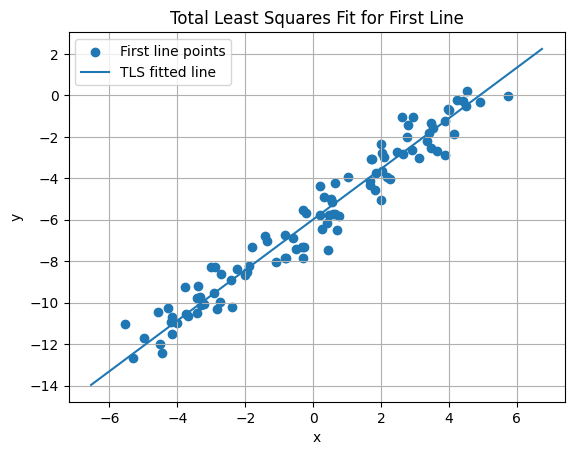

In [1]:
#Question 1 part (a)

import numpy as np
import matplotlib.pyplot as plt

# Load data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# First line only
x1 = D[:, 0]
y1 = D[:, 3]

# Stack points
P = np.column_stack((x1, y1))

# Compute centroid
centroid = np.mean(P, axis=0)

# Center the points
P_centered = P - centroid

# SVD for Total Least Squares
U, S, Vt = np.linalg.svd(P_centered)

# Direction vector of the line
direction = Vt[0]

# Convert to slope-intercept form: y = mx + c
m = direction[1] / direction[0]
c = centroid[1] - m * centroid[0]

print("TLS line for first dataset:")
print("Slope (m) =", m)
print("Intercept (c) =", c)

# Plot
x_plot = np.linspace(min(x1)-1, max(x1)+1, 100)
y_plot = m * x_plot + c

plt.scatter(x1, y1, label="First line points")
plt.plot(x_plot, y_plot, label="TLS fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Total Least Squares Fit for First Line")
plt.grid(True)
plt.show()



Line 1: y = -0.5269x + 1.9891
Line 2: y = 1.0578x + 1.1126
Line 3: y = 1.1052x + -6.4357


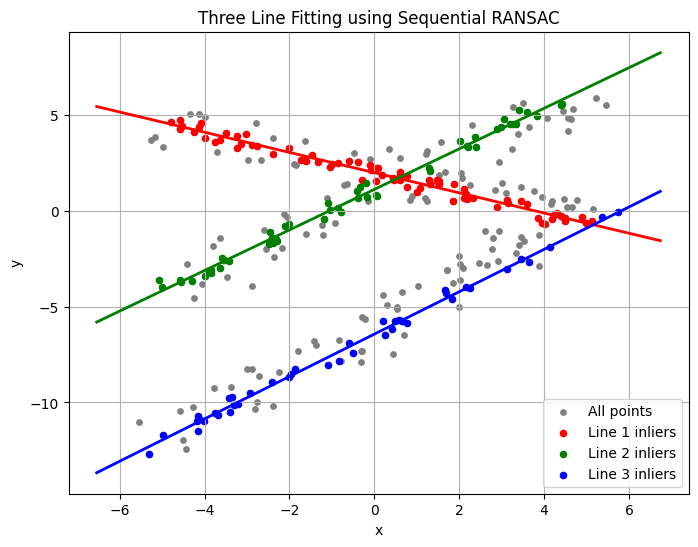

In [2]:
#question 01 part (b)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RANSACRegressor

# Load data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# Extract and flatten all points
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

# Put all points together
points_x = X_all.copy()
points_y = Y_all.copy()

# Store results
lines = []
colors = ['r', 'g', 'b']

plt.figure(figsize=(8, 6))
plt.scatter(points_x, points_y, s=15, color='gray', label='All points')

remaining_x = points_x
remaining_y = points_y

for i in range(3):
    X = remaining_x.reshape(-1, 1)
    y = remaining_y

    # RANSAC
    ransac = RANSACRegressor(
        estimator=LinearRegression(),
        min_samples=2,
        residual_threshold=0.5,
        random_state=42+i
    )
    ransac.fit(X, y)

    # Inliers and outliers
    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask

    # Line parameters
    m = ransac.estimator_.coef_[0]
    c = ransac.estimator_.intercept_
    lines.append((m, c))

    print(f"Line {i+1}: y = {m:.4f}x + {c:.4f}")

    # Plot inliers
    plt.scatter(remaining_x[inlier_mask], remaining_y[inlier_mask],
                s=20, color=colors[i], label=f'Line {i+1} inliers')

    # Plot fitted line
    x_plot = np.linspace(min(remaining_x)-1, max(remaining_x)+1, 100)
    y_plot = m * x_plot + c
    plt.plot(x_plot, y_plot, color=colors[i], linewidth=2)

    # Remove inliers for next iteration
    remaining_x = remaining_x[outlier_mask]
    remaining_y = remaining_y[outlier_mask]

plt.xlabel("x")
plt.ylabel("y")
plt.title("Three Line Fitting using Sequential RANSAC")
plt.legend()
plt.grid(True)
plt.show()